# PROYECTO DE APRENDIZAJE AUTOMÁTICO
# Predicción de la Pérdida de Clientes y Estrategias de Retención para Model Fitness

## Descripción

Descripción del proyecto
La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Análisis exploratorio de datos (EDA)

In [2]:
# Cargar el dataset
df = pd.read_csv('/datasets/gym_churn_us.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [3]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [4]:
# Paso 1: Verificar datos faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


### Observaciones:
No hay datos faltantes

In [5]:
# Paso 2: Resumen estadístico con describe()
print("\nResumen estadístico del dataset:")
df.describe()


Resumen estadístico del dataset:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [6]:
# Paso 3: Comparar valores medios entre los grupos de churn (0 = se quedaron, 1 = se fueron)
print("\nValores medios por grupo de churn:")
churn_means = df.groupby('Churn').mean()
churn_means


Valores medios por grupo de churn:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


In [7]:
# Paso 4: Crear histogramas de barras y distribuciones para características numéricas
# Seleccionar columnas numéricas
numeric_cols = ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 
                'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

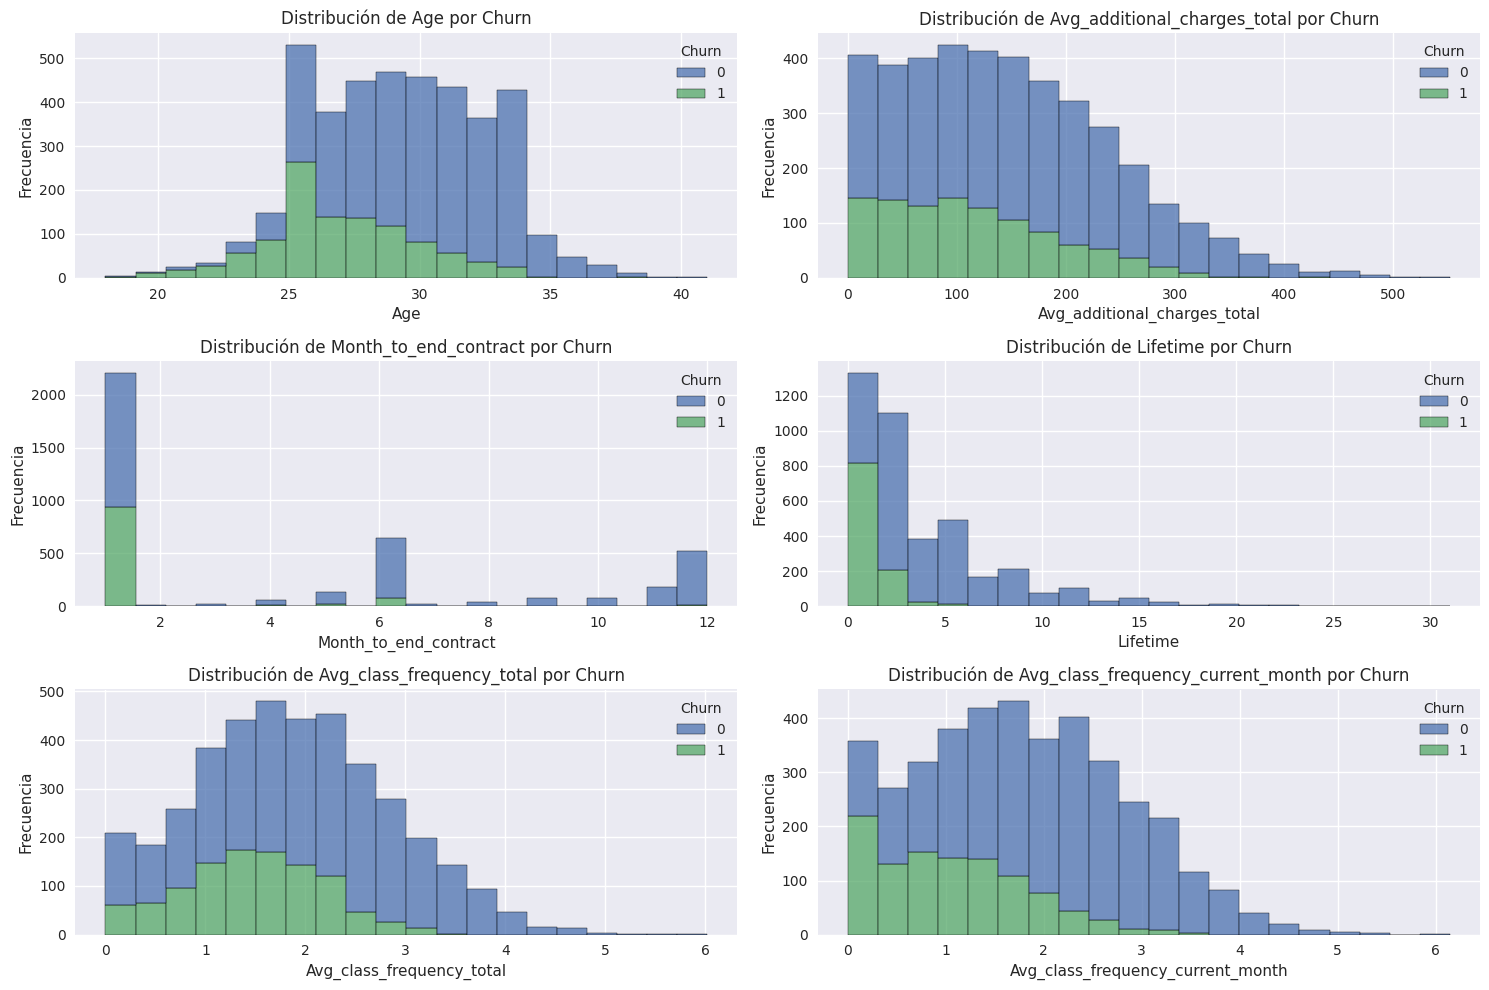

In [8]:
# Configurar el estilo de los gráficos
plt.style.use('seaborn')

# Crear una figura para histogramas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df, x=col, hue='Churn', multiple='stack', bins=20)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Observaciones:
- La mayor cantidad de usuarios, se encuentra en un rango de edad de entre 25 y 34 años.
- Los usuarios de entre 25 y 26 años, son los que más abandonan el gimnasio.
- También hay una cantidad significativa de usuarios de entre 26 y 34 años que abandonan.
- De 35 años en adelante, no abandonan (usuarios leales), pero son la menor cantidad de usuarios.
- En cuanto a gastos totalte promedio adicionales en el gimnasio, los usuarios que más abandonan son aquellos que no gastaron (0 USD) hasta los que gastan 300 USD. Los que gastan más de 300 USD adicionales, no abandonan el gimnasio (usuarios leales).
- La distribución de "meses hasta que acabe el contrato", muestra que la gran mayoría de usuarios que abandona, lo hace cuando les falta 1 mes para que acabe su contrato.
- Observando la gráfica de distribución por tiempo de vida, los usuarios que abandonaron el gimnasio, lo hicieron antes de cumplir 5 meses visitándolo.
- Los usuarios que llevan, por lo menos, 5 meses en el gimasio; no lo abandonan (usuarios leales).
- Los usuarios que visitan el gimnasio entre 0 y 2 veces a la semana, son los que más abandonan. Aunque también hay una gran cantidad de usuarios en ese mismo rango, que no abandoron el gimnasio.
- Los usuarios que van al gimanio 3 o más veces a la semana, son menos propensos a abandonar (usuarios leales).
- En el mes en curso, los usuarios que abandonaron el gimnasio, fueron aquellos que iban entre 0 y 2 veces a la semana.

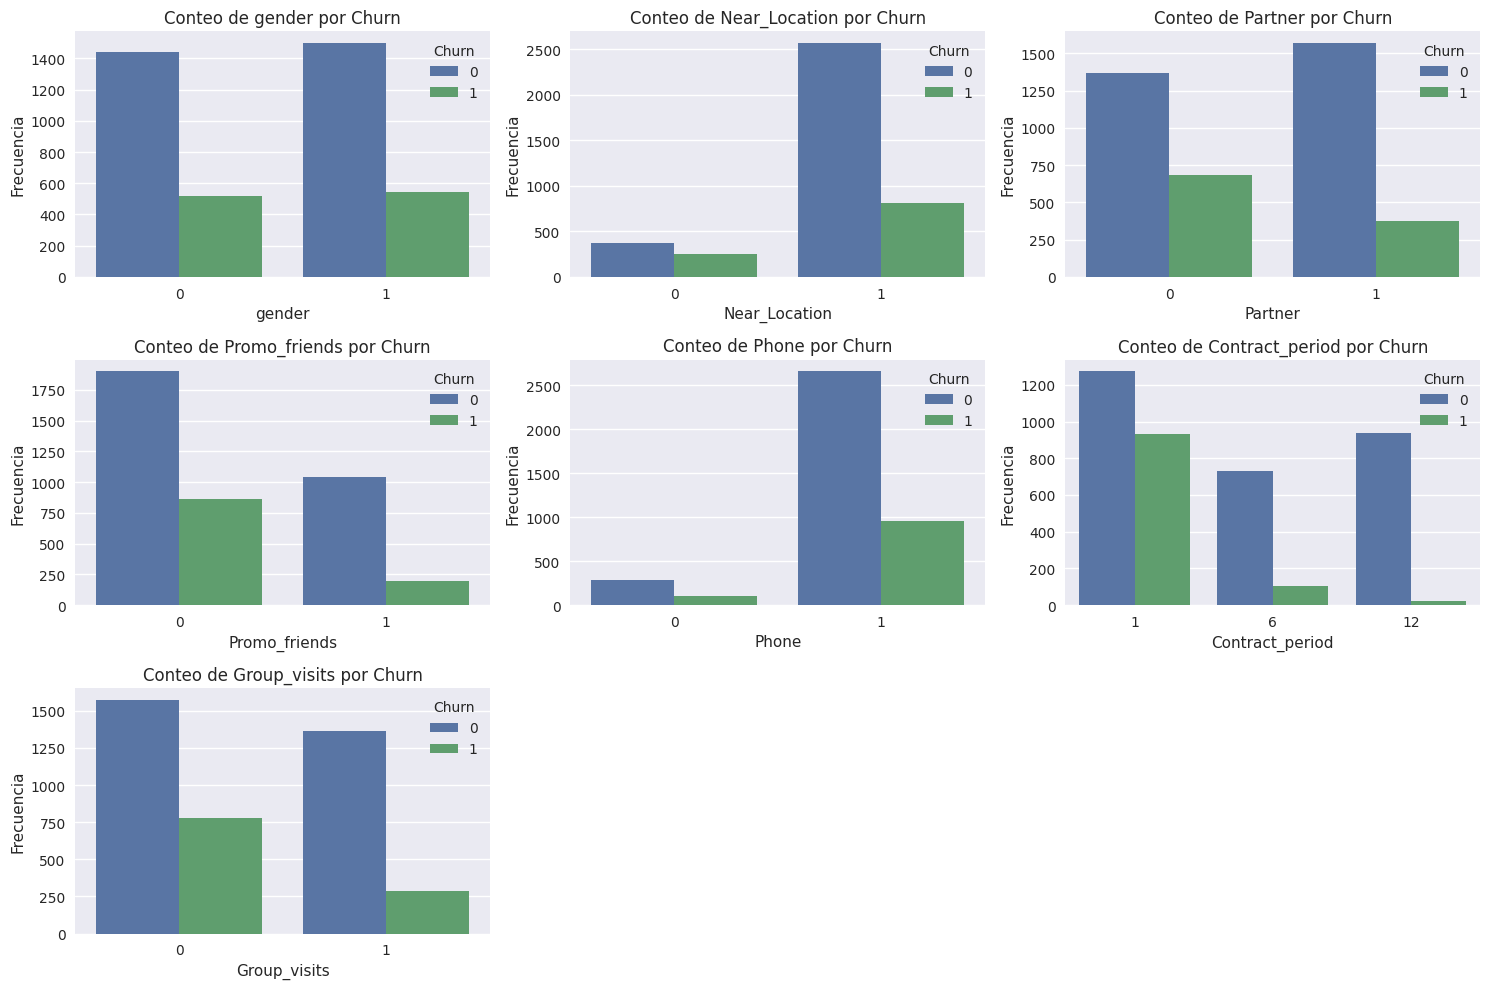

In [9]:
# Crear histogramas para características categóricas
categorical_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 
                    'Contract_period', 'Group_visits']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Conteo de {col} por Churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Observaciones:
- Por género, no hay una diferencia notable entre los usuarios que abandonan el gimnasio, es decir, que hombres y mujeres son igual de propensos a abandonar el gimnasio.
- En cuanto a usuarios cuyos domicilios están cercanos o lejanos al gimnasio, en proporción, los que viven lejos son más propensos a bandonar que los que viven cerca.
- Observando el gráfico de abandono de gimnasio por usuarios empleados en compañías asociadas o no; se nota que los usuarios que trabajan en compañías NO asociadas al gimnasio, tienen más propensión a bandonar el gimnasio.
- Una situación similar, ocurre con los usuarios que NO fueron invitados por amigos que visitan el gimanasio, en otras palabras, los usuarios que NO llegaron por una "promoción de amigos"; son más propensos a dejar de ir al gimnasio.
- En cuanto a si el  usuario aportó o no su teléfono, no parece influir en si el usuario se va se queda; pues en ambos casos, la propoción de usuarios que dejaron el gimnasio es significativa.
- Para el caso de la duración del contrato, los usuarios que contrataron sólo 1 mes; son los más propensos a abandonar. Los de 6 meses abandonan menos y los de 12 meses aún menos (usuarios leales).
- La gráfica de sesiones grupales, muestra que los usuarios que participaron en dichas sesiones; son menos propensos a abandonar que los que NO asistieron a las sesiones.

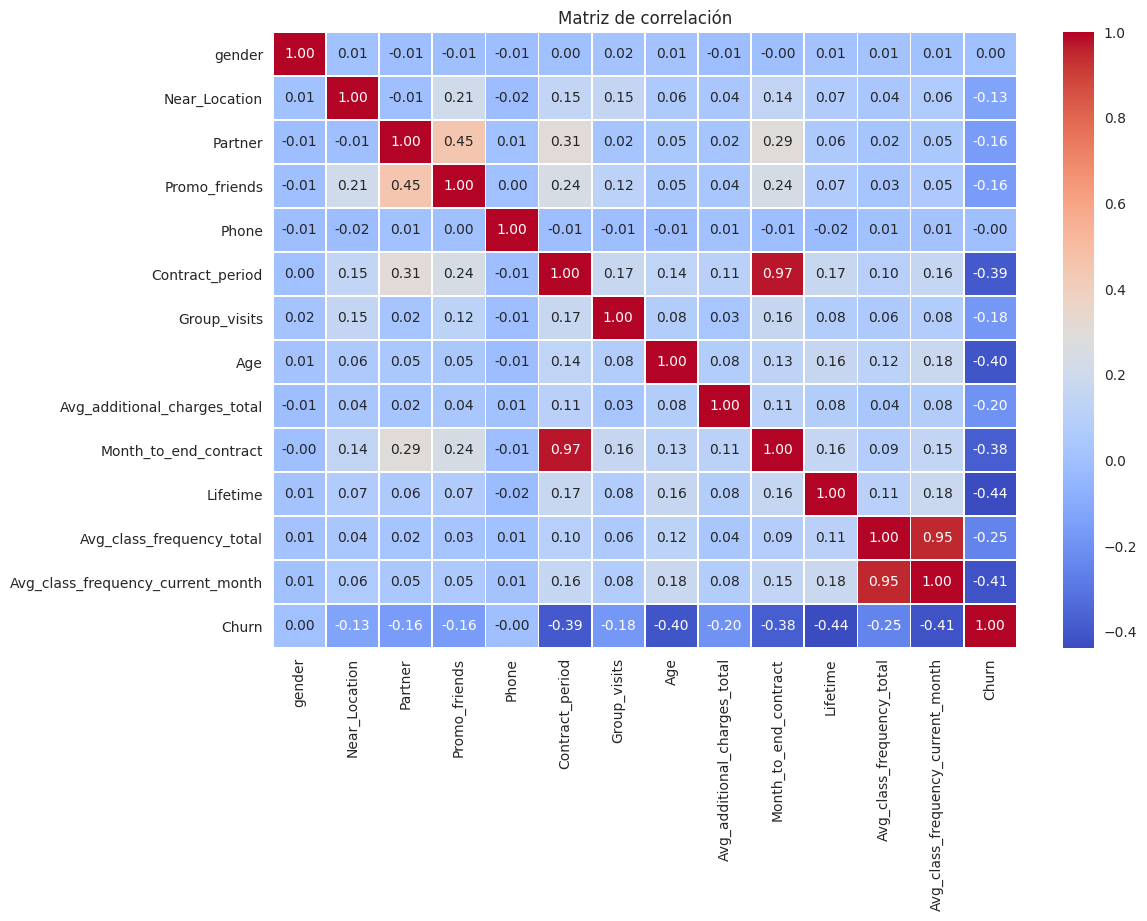

In [10]:
# Paso 5: Crear y mostrar la matriz de correlación
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación')
plt.show()

### Observaciones:
Los parámetros que más correlación (inversamente proporcional) con el parámetro de abandono, son: periodo de vida, edad, promedio de clases tomadas en el mes en curso, periodo de contrato y meses para finalizar el contrato.

# 2. Construir un modelo para predecir la cancelación de usuarios

In [11]:
# Separar características (X) y variable objetivo (y)
X = df.drop('Churn', axis=1)  # Todas las columnas excepto 'Churn'
y = df['Churn']  # Variable objetivo

# Dividir los datos en conjuntos de entrenamiento y validación (80% entrenamiento, 20% validación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar los modelos
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(random_state=42)

# Entrenar el modelo de regresión logística
log_reg.fit(X_train, y_train)

# Entrenar el modelo de bosque aleatorio
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# Predecir con ambos modelos en el conjunto de validación
y_pred_log_reg = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Calcular métricas para regresión logística
print("Métricas para Regresión Logística:")
print(f"Exactitud: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precisión: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")

# Calcular métricas para bosque aleatorio
print("\nMétricas para Bosque Aleatorio:")
print(f"Exactitud: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precisión: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")

Métricas para Regresión Logística:
Exactitud: 0.9163
Precisión: 0.8729
Recall: 0.7822

Métricas para Bosque Aleatorio:
Exactitud: 0.9100
Precisión: 0.8495
Recall: 0.7822


### Observaciones:
El entrenamiento del modelo con el métoo de "Regresión Logística", mostró resultados marginalmente mejores que el método de entrenamiento de "Bosque Aleatorio".

# 3. Crear clústeres de usuarios/as

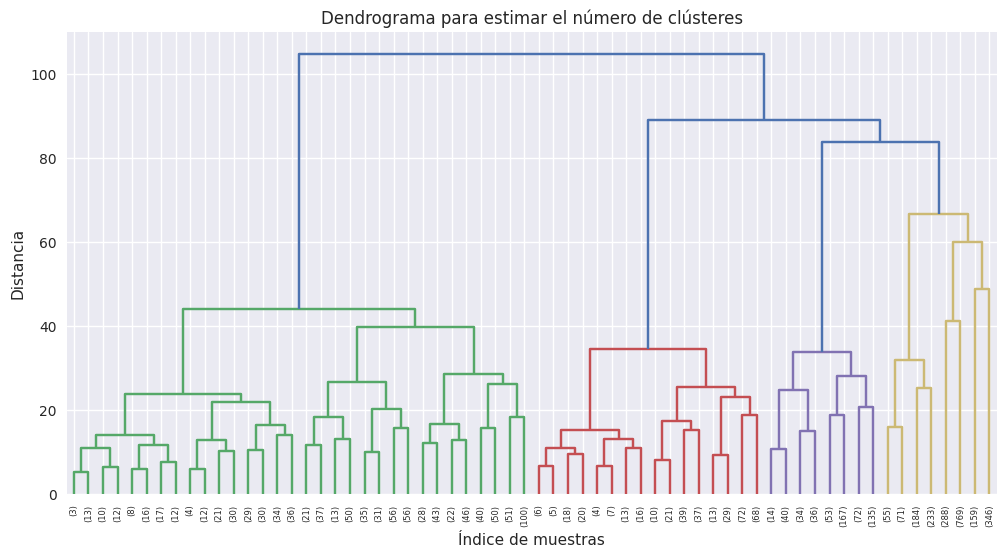

In [13]:
# Paso 1: Dejar de lado la columna 'Churn' para clustering
X = df.drop('Churn', axis=1)

# Paso 2: Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 3: Crear matriz de distancias y dendrograma
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, orientation='top', truncate_mode='level', p=5)
plt.title('Dendrograma para estimar el número de clústeres')
plt.xlabel('Índice de muestras')
plt.ylabel('Distancia')
plt.show()

In [14]:
# Paso 4: Entrenar el modelo K-means con n=5 clústeres
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Añadir los clústeres al DataFrame original
df['Cluster'] = clusters

# Paso 5: Calcular valores medios de características por clúster
print("\nValores medios de características por clúster:")
cluster_means = df.groupby('Cluster').mean()
print(cluster_means)


Valores medios de características por clúster:
           gender  Near_Location   Partner  Promo_friends  Phone  \
Cluster                                                            
0        0.502370       0.949447  0.829384       0.998420    1.0   
1        0.554556       0.849269  0.263217       0.052868    1.0   
2        0.499422       0.937572  0.737572       0.478613    1.0   
3        0.485738       0.718011  0.299919       0.018745    1.0   
4        0.523316       0.862694  0.471503       0.305699    0.0   

         Contract_period  Group_visits        Age  \
Cluster                                             
0               3.097946      0.448657  29.104265   
1               2.606299      0.436445  30.008999   
2              11.854335      0.546821  29.905202   
3               1.914425      0.276284  28.083945   
4               4.777202      0.427461  29.297927   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                      

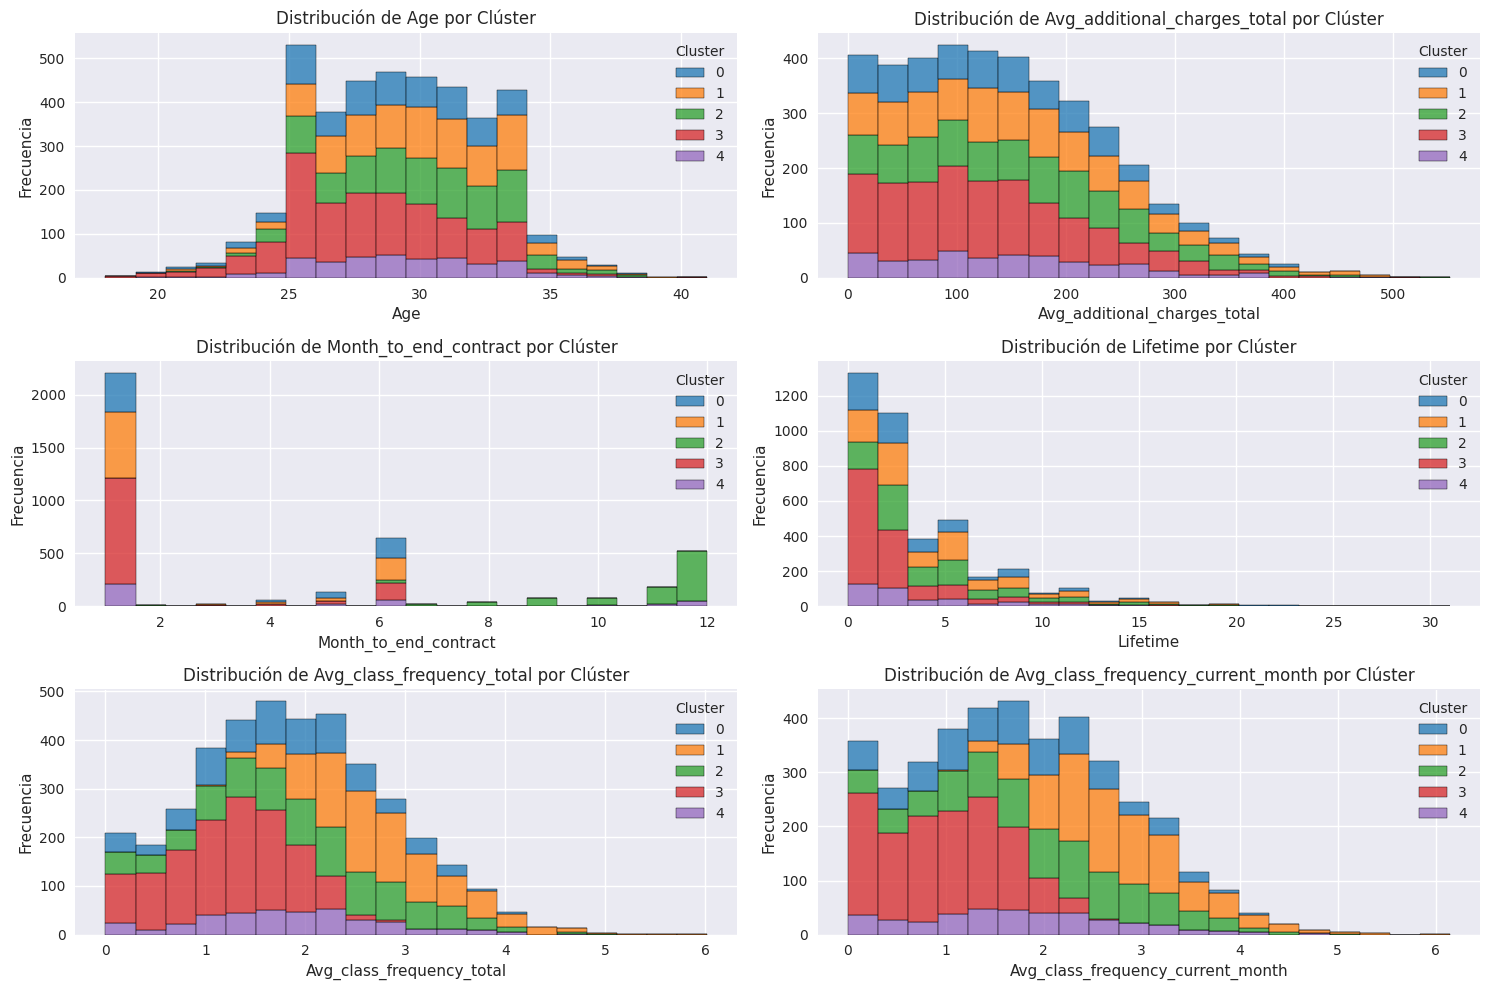

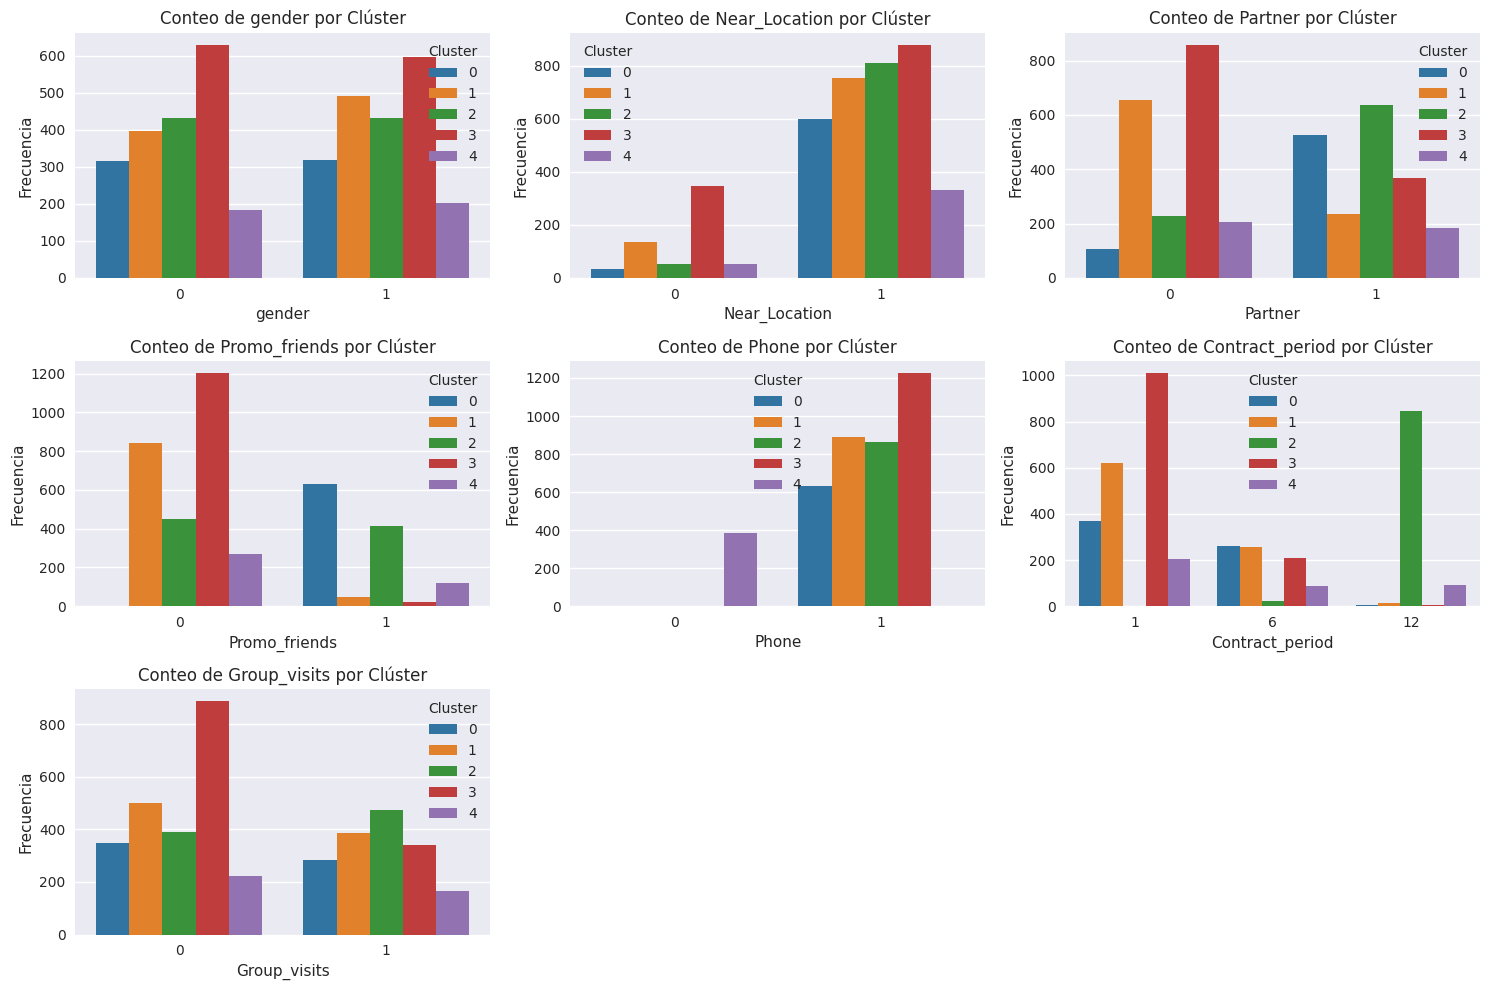

In [15]:
# Paso 6: Trazar distribuciones de características para los clústeres
numeric_cols = ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 
                'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
categorical_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 
                    'Contract_period', 'Group_visits']

# Distribuciones para variables numéricas
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df, x=col, hue='Cluster', multiple='stack', bins=20, palette='tab10')
    plt.title(f'Distribución de {col} por Clúster')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Distribuciones para variables categóricas
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, hue='Cluster', palette='tab10')
    plt.title(f'Conteo de {col} por Clúster')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [16]:
# Paso 7: Calcular la tasa de cancelación (churn) por clúster
print("\nTasa de cancelación por clúster:")
churn_rate = df.groupby('Cluster')['Churn'].mean()
print(churn_rate)

# Comparar clústeres propensos a irse vs. leales
print("\nAnálisis de tasas de cancelación:")
for cluster in churn_rate.index:
    rate = churn_rate[cluster]
    if rate > 0.4:
        print(f"Clúster {cluster}: Alta propensión a irse (tasa de churn: {rate:.4f})")
    elif rate < 0.2:
        print(f"Clúster {cluster}: Leal (tasa de churn: {rate:.4f})")
    else:
        print(f"Clúster {cluster}: Propensión moderada (tasa de churn: {rate:.4f})")


Tasa de cancelación por clúster:
Cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

Análisis de tasas de cancelación:
Clúster 0: Propensión moderada (tasa de churn: 0.2464)
Clúster 1: Leal (tasa de churn: 0.0900)
Clúster 2: Leal (tasa de churn: 0.0220)
Clúster 3: Alta propensión a irse (tasa de churn: 0.5729)
Clúster 4: Propensión moderada (tasa de churn: 0.2668)


### Observaciones:
- Los clústeres 0 y 4, es moderadamente propenso a abandonar el gimnasio; con una tasa de abandono del 24.64% y 26.68% respectivamente.
- Los clústeres 1 y 2, se consideran usuarios leales; con una tasa de abandono del 9% y 2% respectivamente.
- Los usuarios del clúster 3, son áltamente propensos a dejar el gimnasio, con una tasa de abandono del 57.29%

# 4. CONCLUSIONES Y RECOMENDACIONES

## 4.1 Conclusiones:
#### - Los usarios más jóvenes (25 a 29 años), con contratos de 1 mes, que viven lejos del gimnasio y que toman pocas o ninguna clase a la semana; son lo más propensos a abandonar el gimnasio, en menos de 5 meses.
#### - Mientras que, los usuarios de 30 años en adelante, con contratos de entre 6 y 12 meses, que viven cerca del gimnasio y lo frecuentan de forma regular (2 o más veces a la semana) son los más leales y permancen más de 5 meses.

## 4.2 Recomendaciones:

#### 1. Fomentar contratos de mayor duración para aumentar la retención
**Justificación**: Los usuarios con contratos de 1 mes son los más propensos a abandonar, mientras que aquellos con contratos de 6 o 12 meses son más leales, según la fuerte correlación inversa entre la duración del contrato y el churn.

- **Paso de marketing 1**: Ofrecer descuentos progresivos para contratos más largos, por ejemplo, un 10% de descuento en contratos de 6 meses y un 20% en los de 12 meses, destacando el ahorro a largo plazo.
- **Paso de marketing 2**: Crear un programa de "compromiso inicial" que incluya una clase gratuita o una sesión con un entrenador personal para quienes se inscriban en contratos de 6 o 12 meses, reforzando el valor percibido.
- **Paso de marketing 3**: Enviar recordatorios personalizados antes de la renovación del contrato, ofreciendo beneficios adicionales (como un mes gratis) si extienden su contrato a 12 meses.

#### 2. Dirigirse a clientes con alta propensión a abandonar mediante estrategias de engagement
**Justificación**: Los usuarios del clúster 3 (57.29% de churn) son jóvenes, con contratos de 1 mes, que viven lejos y tienen baja frecuencia de visitas. Además, los clientes que no llegaron por "promoción de amigos" o no trabajan en empresas asociadas son más propensos a irse.

- **Paso de marketing 1**: Lanzar un programa de "embajadores de amigos" que ofrezca incentivos (como una semana gratis) a los clientes que traigan a un amigo, especialmente dirigido a los usuarios del clúster 3 para aumentar su conexión social con el gimnasio.
- **Paso de marketing 2**: Crear alianzas con más empresas locales para incluir a sus empleados como "socios", ofreciendo descuentos corporativos que incentiven la retención de clientes que no trabajan en empresas asociadas actualmente.
- **Paso de marketing 3**: Enviar correos electrónicos o notificaciones push personalizadas a los usuarios jóvenes con contratos de 1 mes, sugiriendo clases grupales gratuitas o retos de fitness de 30 días para aumentar su frecuencia de visitas y compromiso.

#### 3. Atraer y retener a usuarios de 30 años en adelante con programas personalizados
**Justificación**: Los usuarios de 30 años en adelante, especialmente en los clústeres 1 y 2 (tasas de churn de 9% y 2%), son más leales y permanecen más de 5 meses, según la correlación inversa entre la edad y el churn. Atraer a este grupo demográfico fortalecerá la base de clientes leales.

- **Paso de marketing 1**: Diseñar programas de fitness dirigidos a mayores de 30 años, como clases de bajo impacto (yoga restaurativo, pilates) o talleres de bienestar integral (nutrición, manejo del estrés), promocionados en canales frecuentados por este grupo, como redes sociales profesionales o eventos comunitarios.
- **Paso de marketing 2**: Ofrecer paquetes de membresía exclusivos para mayores de 30 años, que incluyan beneficios como consultas periódicas con entrenadores personales o descuentos en servicios de spa y masajes, destacando un enfoque en salud a largo plazo.
- **Paso de marketing 3**: Crear campañas de marketing dirigidas a este grupo, utilizando testimonios de clientes leales mayores de 30 años que resalten cómo el gimnasio ha mejorado su calidad de vida, distribuidas en medios locales y plataformas digitales como Facebook o LinkedIn.
#### 4. Personalizar la experiencia para clientes que viven lejos del gimnasio
**Justificación**: Los usuarios que viven lejos del gimnasio son más propensos a abandonar, especialmente en el clúster 3, lo que indica una barrera de acceso relacionada con la distancia.

- **Paso de marketing 1**: Ofrecer clases virtuales en vivo o grabadas como un beneficio adicional para los clientes que viven lejos, permitiéndoles participar sin necesidad de desplazarse al gimnasio.
- **Paso de marketing 2**: Proporcionar incentivos de transporte, como descuentos en servicios de ridesharing (por ejemplo, Uber) para asistir al gimnasio, o asociarse con empresas locales para ofrecer estacionamiento gratuito o subsidiado.
- **Paso de marketing 3**: Enviar mensajes personalizados a los clientes que viven lejos, destacando eventos especiales o promociones en el gimnasio que justifiquen el viaje, como talleres de fitness o sesiones con entrenadores reconocidos.

Estas estrategias se centran en los grupos objetivo identificados (clústeres 0, 3 y 4 para reducir el churn; clústeres 1 y 2 para mantener la lealtad) y aprovechan los patrones observados para maximizar la retención de clientes.